# RL Agent for Game Playing

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a game-playing RL agent
- Train and evaluate in a game environment

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson uses a simple game to show why games are one of the clearest environments for reinforcement learning.

Students will see how state, action, reward, and repeated episodes naturally appear in game settings.

Why this matters: game-playing examples make RL concrete and easy to visualize.

This lesson helps students connect abstract RL ideas to visible outcomes.

## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Build an Mario AI Model with Python | Gaming Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=2eeYqJ0uBKE)

Why this pick:
- game-focused practical workflow.
- Shows how an RL agent is built around a playable environment, preprocessing, and training loop.
- A strong fit for students connecting RL to actual game-playing agents.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Turn-based environment: players act one after another.
- Opponent effect: another player changes the dynamics.
- Win condition: what counts as success.
- Strategy learning: improving through repeated play.
- Delayed consequence: one move can matter several turns later.

### Quick Check
- Why are games useful for learning RL?
- How do state, action, and reward appear in the game?
- What changes when another player is involved?
- Why can a move be good even if it gives no immediate reward?

### Common Mistakes
- Focusing on game rules but missing RL structure.
- Assuming learning happens instantly.
- Ignoring how the opponent changes the problem.
- Judging moves only by immediate reward instead of long-term position.


## Why Games Are Such a Natural RL Example

Games are one of the clearest ways to teach reinforcement learning because the loop is easy to see:

- observe the board or game state
- choose a move
- see the result
- repeat until the game ends

### What students should notice

A game is not only a set of rules.
It is also a sequential decision process with delayed consequences.

A move can be valuable because it creates a better future position, even if the reward is not immediate.

### Why this matters beyond games

The reason games are useful is not that RL is only for games.
It is that games make the RL structure visible, so students can later transfer the same thinking to robotics, recommendation, and operations problems.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Print text to the notebook cell output (console).
print('✅ Setup complete!')


✅ Setup complete!


## Part 1: Simple Game Environment (Tic-Tac-Toe)


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `TicTacToe` (what it does): Simple Tic-Tac-Toe game environment.
class TicTacToe:
    """Simple Tic-Tac-Toe game environment."""
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Assign/update a variable used later in this cell or in other cells.
        self.board = np.zeros((3, 3), dtype=int)

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def reset(self):
        # Assign/update a variable used later in this cell or in other cells.
        self.board[:] = 0
        # Return a value from this function to its caller.
        return self.board.copy()

    # Function `available_actions` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def available_actions(self):
        # Return a value from this function to its caller.
        return [(r, c) for r in range(3) for c in range(3) if self.board[r, c] == 0]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action, player.
    def step(self, action, player=1):
        # Assign/update a variable used later in this cell or in other cells.
        r, c = action
        # Branch: only run the next indented lines when this condition is true.
        if self.board[r, c] != 0:
            # Return a value from this function to its caller.
            return self.board.copy(), -5, True, {"invalid": True}
        # Assign/update a variable used later in this cell or in other cells.
        self.board[r, c] = player
        # Unpack the one-step model output from transition(state, action).
        reward = 1 if self.check_winner(player) else 0
        # Assign/update a variable used later in this cell or in other cells.
        done = reward == 1 or len(self.available_actions()) == 0
        # Return a value from this function to its caller.
        return self.board.copy(), reward, done, {"invalid": False}

    # Function `check_winner` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, player.
    def check_winner(self, player):
        # Assign/update a variable used later in this cell or in other cells.
        rows = np.any(np.sum(self.board == player, axis=1) == 3)
        # Assign/update a variable used later in this cell or in other cells.
        cols = np.any(np.sum(self.board == player, axis=0) == 3)
        # Assign/update a variable used later in this cell or in other cells.
        diag1 = np.sum(np.diag(self.board == player)) == 3
        # Assign/update a variable used later in this cell or in other cells.
        diag2 = np.sum(np.diag(np.fliplr(self.board == player))) == 3
        # Return a value from this function to its caller.
        return rows or cols or diag1 or diag2


## Part 2: Q-Learning Agent


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `QLearningAgent` (what it does): Minimal Q-learning agent for demonstration only.
class QLearningAgent:
    """Minimal Q-learning agent for demonstration only."""
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, learning_rate, gamma, epsilon.
    def __init__(self, learning_rate=0.1, gamma=0.95, epsilon=0.1):
        # Assign/update a variable used later in this cell or in other cells.
        self.learning_rate = learning_rate
        # Assign/update a variable used later in this cell or in other cells.
        self.gamma = gamma
        # Assign/update a variable used later in this cell or in other cells.
        self.epsilon = epsilon
        # Assign/update a variable used later in this cell or in other cells.
        self.q = {}

    # Function `key` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, board.
    def key(self, board):
        # Return a value from this function to its caller.
        return tuple(board.flatten())

    # Function `select_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, env.
    def select_action(self, env):
        # Assign/update a variable used later in this cell or in other cells.
        actions = env.available_actions()
        # Branch: only run the next indented lines when this condition is true.
        if np.random.rand() < self.epsilon:
            # Return a value from this function to its caller.
            return actions[np.random.randint(len(actions))]
        # Assign/update a variable used later in this cell or in other cells.
        state_key = self.key(env.board)
        # Create or choose a variable used in the Bellman warm-up demo.
        values = [self.q.get((state_key, action), 0.0) for action in actions]
        # Return a value from this function to its caller.
        return actions[int(np.argmax(values))]


# Assign/update a variable used later in this cell or in other cells.
env = TicTacToe()
# Assign/update a variable used later in this cell or in other cells.
agent = QLearningAgent()
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset()
# Assign/update a variable used later in this cell or in other cells.
action = agent.select_action(env)
# Print text to the notebook cell output (console).
print("Selected opening action:", action)


Selected opening action: (0, 0)


## Real-World Applications

- **Chess/Go**: DeepMind AlphaZero
- **Video Games**: Dota 2, StarCraft II
- **Board Games**: Tic-Tac-Toe, Connect 4, Checkers
- **Puzzle Games**: Rubik's Cube solving

### Why this lesson matters

Games are often the cleanest place to understand RL because the rules are clear,
episodes reset easily, and success is easy to observe.

## Worked Example: Why Games Are Good RL Testbeds

Games are useful in RL because they usually provide:
- clear rules
- a known action space
- easy reset between episodes
- a visible success condition

Below, you will compare a simple game-playing strategy against a random opponent.
The point is not to build AlphaZero here. The point is to see how state,
actions, rewards, and repeated episodes naturally fit the RL setup.

Teaching note: this example is mostly about **problem structure and decision logic**. It should not be presented as a full learned Q-learning or deep-RL game agent.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `winning_move` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env, player.
def winning_move(env, player):
    # Loop header: repeat the indented block for each item in the iterable.
    for action in env.available_actions():
        # Assign/update a variable used later in this cell or in other cells.
        board_backup = env.board.copy()
        # Assign/update a variable used later in this cell or in other cells.
        _, reward, done, _ = env.step(action, player=player)
        # Assign/update a variable used later in this cell or in other cells.
        env.board = board_backup
        # Branch: only run the next indented lines when this condition is true.
        if done and reward == 1:
            # Return a value from this function to its caller.
            return action
    # Return a value from this function to its caller.
    return None


# Function `center_then_random` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env.
def center_then_random(env):
    # Branch: only run the next indented lines when this condition is true.
    if env.board[1, 1] == 0:
        # Return a value from this function to its caller.
        return (1, 1)
    # Assign/update a variable used later in this cell or in other cells.
    actions = env.available_actions()
    # Return a value from this function to its caller.
    return actions[np.random.randint(len(actions))]


# Function `play_game` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy_player.
def play_game(policy_player=1):
    # Assign/update a variable used later in this cell or in other cells.
    env = TicTacToe()
    # Execute: env.reset()
    env.reset()
    # Assign/update a variable used later in this cell or in other cells.
    current_player = 1

    # Loop header: repeat while the condition stays true.
    while True:
        # Branch: only run the next indented lines when this condition is true.
        if current_player == policy_player:
            # Assign/update a variable used later in this cell or in other cells.
            action = winning_move(env, current_player)
            # Branch: only run the next indented lines when this condition is true.
            if action is None:
                # Assign/update a variable used later in this cell or in other cells.
                action = center_then_random(env)
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Assign/update a variable used later in this cell or in other cells.
            action = env.available_actions()[np.random.randint(len(env.available_actions()))]

        # Assign/update a variable used later in this cell or in other cells.
        _, reward, done, _ = env.step(action, player=current_player)
        # Branch: only run the next indented lines when this condition is true.
        if done:
            # Branch: only run the next indented lines when this condition is true.
            if reward == 1:
                # Return a value from this function to its caller.
                return current_player
            # Return a value from this function to its caller.
            return 0
        # Assign/update a variable used later in this cell or in other cells.
        current_player = 2 if current_player == 1 else 1


# Assign/update a variable used later in this cell or in other cells.
results = {1: 0, 2: 0, 0: 0}
# Loop header: repeat the indented block for each item in the iterable.
for _ in range(200):
    # Assign/update a variable used later in this cell or in other cells.
    winner = play_game(policy_player=1)
    # Assign/update a variable used later in this cell or in other cells.
    results[winner] += 1

# Print text to the notebook cell output (console).
print("Results over 200 games:")
# Print text to the notebook cell output (console).
print(" Policy player wins:", results[1])
# Print text to the notebook cell output (console).
print(" Random opponent wins:", results[2])
# Print text to the notebook cell output (console).
print(" Draws:", results[0])

# Print text to the notebook cell output (console).
print("\nTeaching point:")
# Print text to the notebook cell output (console).
print("Games are useful RL environments because the agent can play many episodes,")
# Print text to the notebook cell output (console).
print("observe wins and losses, and gradually improve its policy from repeated experience.")


Results over 200 games:
 Policy player wins: 180
 Random opponent wins: 15
 Draws: 5

Teaching point:
Games are useful RL environments because the agent can play many episodes,
observe wins and losses, and gradually improve its policy from repeated experience.


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## Summary

This notebook showed why games are a natural RL application area:

- the state is the board configuration
- actions are legal moves
- rewards can represent wins, losses, or draws
- the environment resets cleanly for repeated practice

### Main takeaway

Game-playing problems make RL ideas concrete because students can easily see how
better decisions lead to better outcomes over many episodes.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


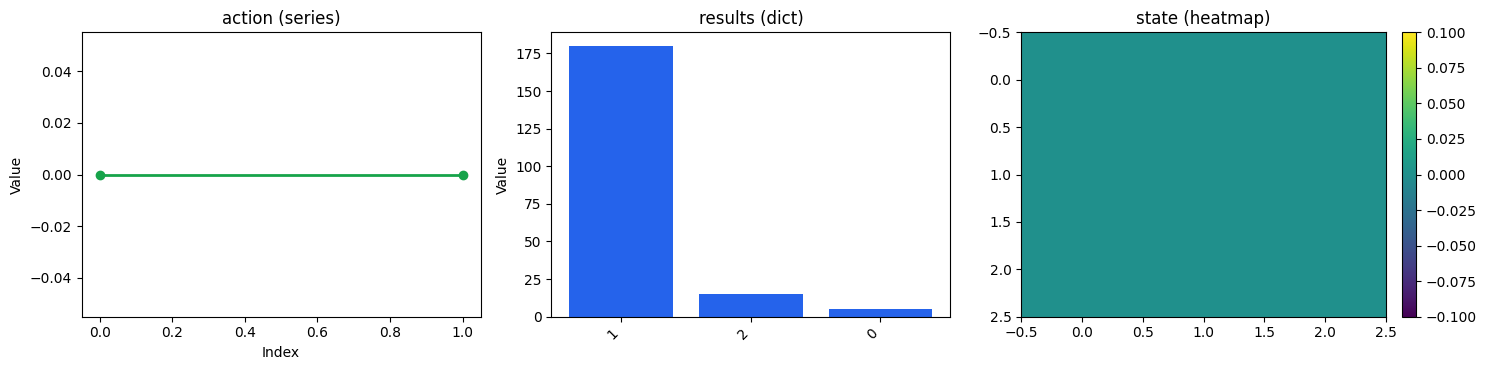

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Games are useful RL testbeds because actions, feedback, and consequences are easy to observe and discuss clearly.

**If students remember one idea:** Game-playing examples help students see decision quality across many repeated interactions, which is central to RL thinking.

**Quick check before moving on:**
- Can you explain why games are good environments for testing RL ideas?
- Can you describe what makes a game strategy better than a short-term greedy move?

**Bridge to the next step:** After games, students can transfer the same sequential-decision thinking to resource optimization problems.
